### import libraries

In [60]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

### Transmission

In [61]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

### reading and plotting

In [62]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [63]:
from collections import OrderedDict


def data_from_folder(folder_path):

    # print(os.listdir(folder_path))

    # Initialize the top-level dictionary to store accumulated arrays for each seed duration
    accumulated_arrays = {}

    for runs_duration_folder in os.listdir(folder_path):
        # Specify the path to the folder containing the saved files
        runs_path = folder_path + '/' + runs_duration_folder

        # Find the YAML file in the folder
        yaml_file = None
        for file_name in os.listdir(runs_path):
            if file_name.endswith('.yaml'):
                yaml_file = os.path.join(runs_path, file_name)
                break

        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue

        # Read the YAML file to get the seed duration value
        with open(yaml_file, 'r') as f:
            yaml_data = yaml.safe_load(f)
            duration_value = yaml_data['seed_duration_FWHM_t']
            
            # seed_FEL_bandwidth = yaml_data['seed_FEL_bandwidth']
            tgrid = yaml_data['tgrid']
            xgrid = yaml_data['xgrid']
            ygrid = yaml_data['ygrid']
            zgrid = yaml_data['zgrid']
            sigma1_Ka1_2p3 = yaml_data['sigma1_Ka1_2p3']
            sigma1_Ka1_other = yaml_data['sigma1_Ka1_other']
            E_seed_uJ = yaml_data['E_seed_uJ']
            
            aux_data = [tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, E_seed_uJ]

        # Initialize variables to store the accumulated arrays for the current duration
        if duration_value not in accumulated_arrays:
            accumulated_arrays[duration_value] = {}

        # Iterate over all files in the folder
        for file_name in os.listdir(runs_path):
            # Check if the file is a numpy savez_compressed file
            if file_name.endswith('.npz'):
                # Load the file
                file_path = os.path.join(runs_path, file_name)
                data = np.load(file_path)

                # Iterate over all arrays in the loaded file
                for array_name in data.files:
                    # Accumulate the arrays by averaging them
                    if array_name in accumulated_arrays[duration_value]:
                        accumulated_arrays[duration_value][array_name] += data[array_name]
                    else:
                        accumulated_arrays[duration_value][array_name] = data[array_name]

        # Divide each accumulated array by the number of files to get the average
        num_files = len([file_name for file_name in os.listdir(runs_path) if file_name.endswith('.npz')])
        # print(f'seed duration: {duration_value}, num_files: {num_files}')
        for array_name in accumulated_arrays[duration_value]:
            accumulated_arrays[duration_value][array_name] /= num_files

    # Sort the accumulated arrays by seed duration value
    sorted_accumulated_arrays = OrderedDict(sorted(accumulated_arrays.items(), key=lambda x: x[0], reverse=True))

    # Example of how to access the accumulated arrays for a specific duration
    # for duration_value, arrays in sorted_accumulated_arrays.items():
    #     print(f'seed duration: {duration_value}')
    #     for array_name, array_data in arrays.items():
    #         print(f'  Array name: {array_name}, shape: {array_data.shape}')
    
    return sorted_accumulated_arrays, aux_data, num_files

In [64]:
data_path = "../data/duration_sweep_23959041"

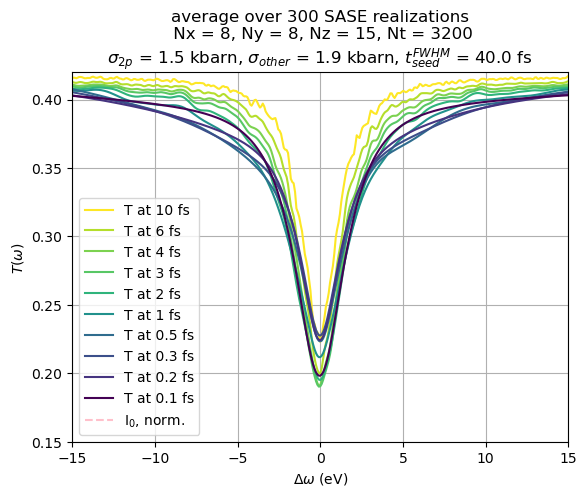

In [65]:
Tshow_min = 0.15#0.4
Tshow_max = 0.42#0.5
w_show = 15
w_show_min = -w_show
w_show_max = w_show

sorted_accumulated_arrays, aux_data, num_files = data_from_folder(data_path)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t = aux_data

plt.figure()

str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
str_pars_calc = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' + \
r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f}' +' fs'

plt.title('average over ' + str(num_files) + ' SASE realizations' + '\n'
+ str_pars_grid + '\n' + str_pars_calc
 )          

duration_values = list(sorted_accumulated_arrays.keys())
norm = plt.matplotlib.colors.LogNorm(vmin=min(duration_values), vmax=max(duration_values))
cmap = plt.matplotlib.colormaps['viridis']

for duration_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    I_int_thy_w_last = I_int_thy_w_last + 0.00001 * max(I_int_thy_w_last)
    I_int_thy_w_0 = I_int_thy_w_0 + 0.00001 * max(I_int_thy_w_0)
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0
    
    plt.plot(womega_ar, Tint_w, color=cmap(norm(duration_value)), label = 'T at '+ str(duration_value) + ' fs')
    
plt.plot(womega_ar, Tshow_min + (Tshow_max-Tshow_min) * arrays['I_int_thy_w_0']/max(arrays['I_int_thy_w_0']),'--', color='pink', label = r'I$_0$, norm.')
plt.ylabel(r'$T(\omega$) ')
plt.xlabel(r'$\Delta\omega$ (eV)')
plt.xlim(w_show_min, w_show_max)
plt.ylim(Tshow_min,Tshow_max)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/' + str_pars_calc + '.pdf')
plt.show()

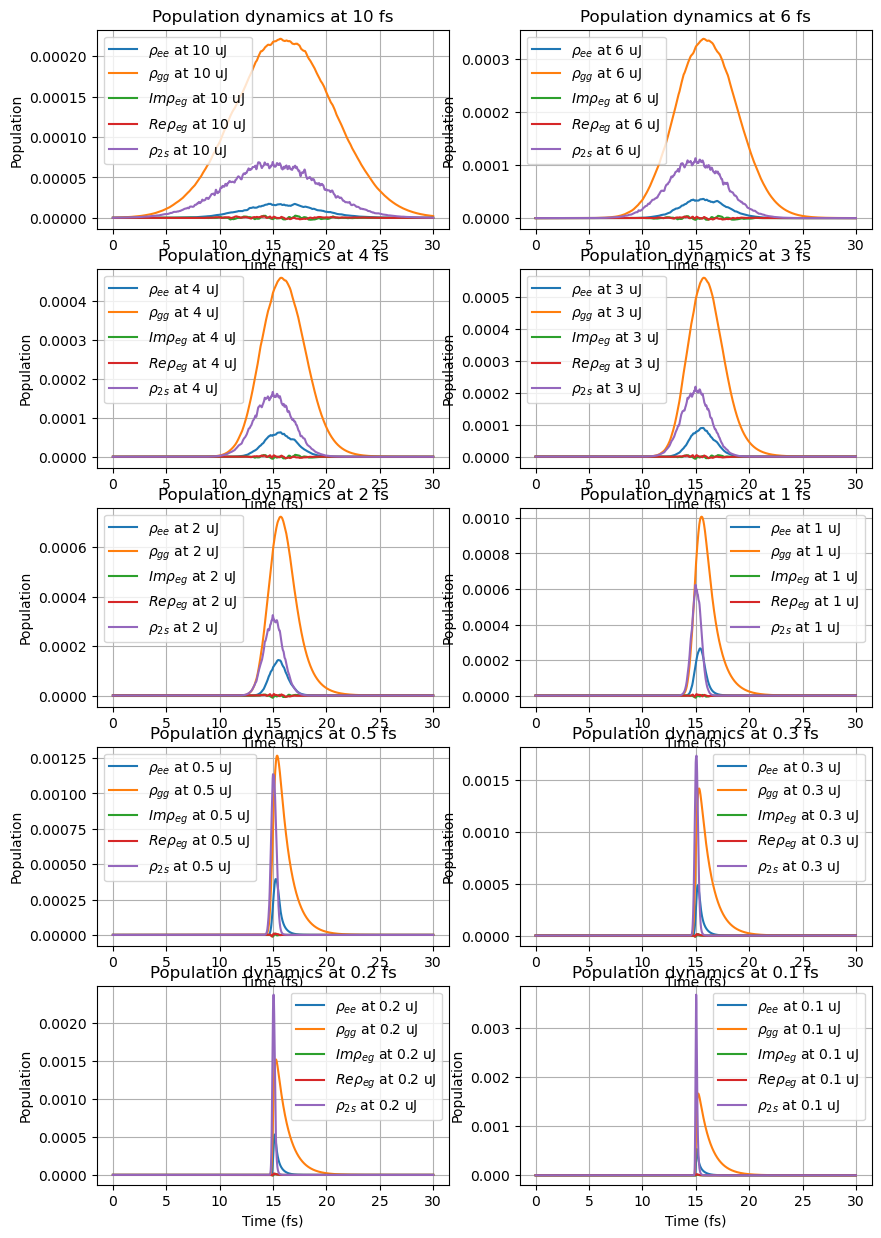

In [67]:
fig, axs = plt.subplots(5, 2, figsize=(10, 15))

i = 0
for duration_value, arrays in sorted_accumulated_arrays.items():
    rho_ee_t_last = arrays['rho_ee_t_last']
    rho_gg_t_last = arrays['rho_gg_t_last']
    rho_eg_t_last = arrays['rho_eg_t_last']
    rho_ground_t_last = arrays['rho_ground_t_last']
    rho_other_t_last = arrays['rho_other_t_last']
    rho_2s_t_last = arrays['rho_2s_t_last']
    t_axis = arrays['t_axis']

    # Plot 2x2 grid of subplots, for example, plotting rho_ee, rho_gg, rho_eg, and rho_ground
    row = i // 2  # Determine the row index based on the duration value
    col = i % 2   # Determine the column index based on the duration value
    axs[row, col].plot(t_axis, rho_ee_t_last, label=rf'$\rho_{{ee}}$ at {duration_value} uJ')
    axs[row, col].plot(t_axis, rho_gg_t_last, label=rf'$\rho_{{gg}}$ at {duration_value} uJ')
    axs[row, col].plot(t_axis, np.imag(rho_eg_t_last), label=rf'$Im\rho_{{eg}}$ at {duration_value} uJ')
    axs[row, col].plot(t_axis, np.real(rho_eg_t_last), label=rf'$Re\rho_{{eg}}$ at {duration_value} uJ')
    axs[row, col].plot(t_axis, rho_2s_t_last, label=rf'$\rho_{{2s}}$ at {duration_value} uJ')
    axs[row, col].set_title(f'Population dynamics at {duration_value} fs')

    i += 1

# Set x and y labels for each subplot
for ax in axs.flat:
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Population')
    ax.legend()
    ax.grid(True)

In [70]:
min_T = []
area_T = []
FWHM_T = []

for duration_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    I_int_thy_w_last = I_int_thy_w_last + 0.00001 * max(I_int_thy_w_last)
    I_int_thy_w_0 = I_int_thy_w_0 + 0.00001 * max(I_int_thy_w_0)
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    mask = (womega_ar > -15) & (womega_ar < 15)
    
    min_T.append(np.min(Tint_w[mask]))
    
    n_edge = 10
    T_base = 0.5 * (
        np.mean(Tint_w[mask][:n_edge]) +
        np.mean(Tint_w[mask][-n_edge:])
    )

    dip = T_base - Tint_w[mask]

    area_T.append(np.trapz(dip))

    FWHM_T.append(tools.find_fwhm(womega_ar[mask], dip))


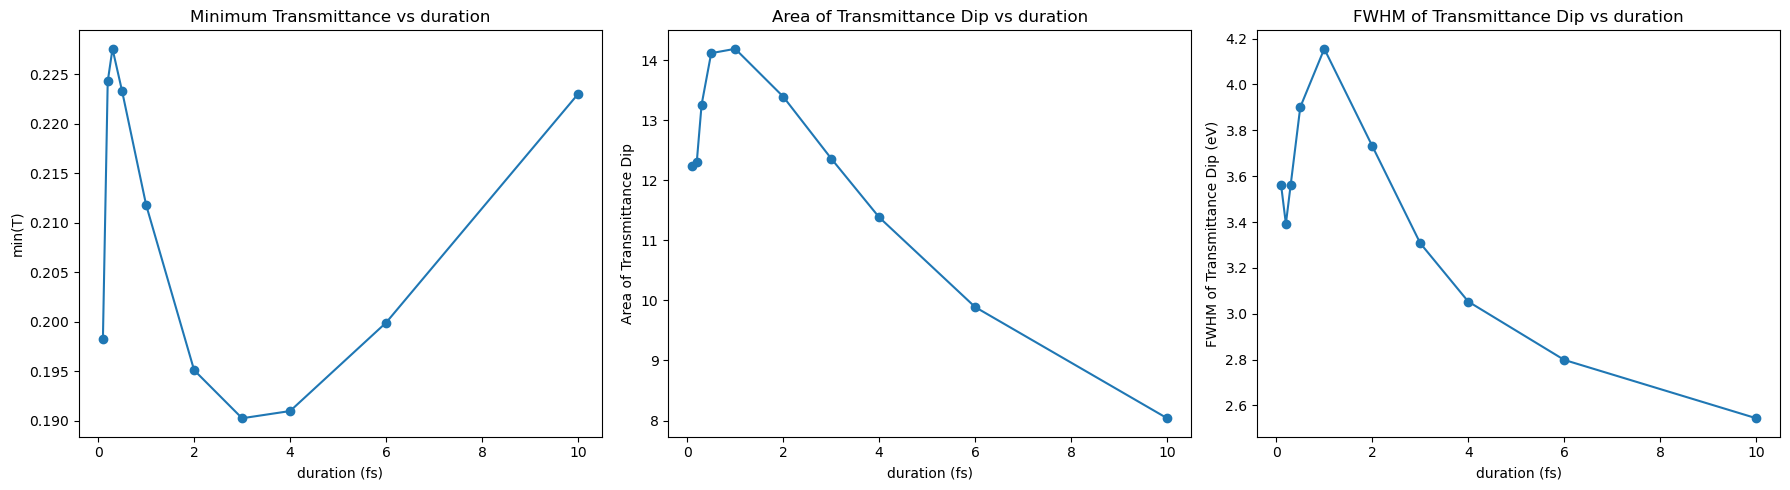

In [71]:
# Plot min_T, area_T, and FWHM_T as functions of E_seed_values in 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(duration_values, min_T, marker='o')
axs[0].set_xlabel('duration (fs)')
axs[0].set_ylabel('min(T)')
axs[0].set_title('Minimum Transmittance vs duration')

axs[1].plot(duration_values, area_T, marker='o')
axs[1].set_xlabel('duration (fs)')
axs[1].set_ylabel('Area of Transmittance Dip')
axs[1].set_title('Area of Transmittance Dip vs duration')

axs[2].plot(duration_values, FWHM_T, marker='o')
axs[2].set_xlabel('duration (fs)')
axs[2].set_ylabel('FWHM of Transmittance Dip (eV)')
axs[2].set_title('FWHM of Transmittance Dip vs duration')

plt.tight_layout()
plt.savefig(figs_path + '/transmittance_metrics_vs_duration.pdf')
plt.show()